In [1]:
!pip install annoy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for annoy: filename=annoy-1.17.3-cp312-cp312-linux_x86_64.whl size=551809 sha256=f4d525337a1e87194eaedf9cbf72bbc2847905e261eaf2613b331b77bdfa3304
  Stored in directory: /root/.cache/pip/wheels/db/b9/53/a3b2d1fe1743abadddec6aa541294b24fdbc39d7800bc57311
Successfully built annoy


In [11]:
from annoy import AnnoyIndex
import numpy as np
import pandas as pd
import joblib
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [26]:
CNN = joblib.load("/content/gdrive/MyDrive/ml/vggFinetune/cnnVGGFinetune.sav")
vgg = joblib.load('/content/gdrive/MyDrive/ml/vggFinetune/vggFinetune.sav')
stdScaler = joblib.load('/content/gdrive/MyDrive/ml/vggFinetune/stdScaler.pkl')
mmScaler = joblib.load('minMaxScaler.pkl')

In [8]:
df = pd.read_csv("/content/gdrive/MyDrive/ml/vggFinetune/trainValiVectors.csv")
filenames = df["filename"].values
vectors = df.drop(columns=["filename"]).values

In [9]:
vector_dim = vectors.shape[1]
ann_index = AnnoyIndex(vector_dim, metric='euclidean')

for i, v in enumerate(vectors):
    ann_index.add_item(i, v.tolist())

ann_index.build(1000)
ann_index.save("image_features.ann")

True

In [12]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [30]:
def extract_feature(img_path):
    datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    img = image.load_img(img_path, target_size=(224,224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = datagen.flow(x, batch_size=32, shuffle=False)

    features = vgg.predict(x, verbose=1)
    features = features / np.linalg.norm(features, axis=1, keepdims=True)

    features = stdScaler.transform(features.reshape(1, -1))
    features = features.reshape(-1)
    features = CNN.predict(features.reshape(1, -1))
    features = mmScaler.transform(features)

    return features.flatten()

In [31]:
def find_similar_images(img_path, top_k=10):
    query_vec = extract_feature(img_path)
    idxs = ann_index.get_nns_by_vector(query_vec, top_k, include_distances=True)
    results = [(filenames[i], d) for i, d in zip(idxs[0], idxs[1])]
    return results

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

pathh = '/content/gdrive/MyDrive/ml/train+vali'

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


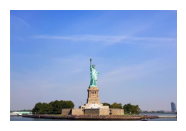

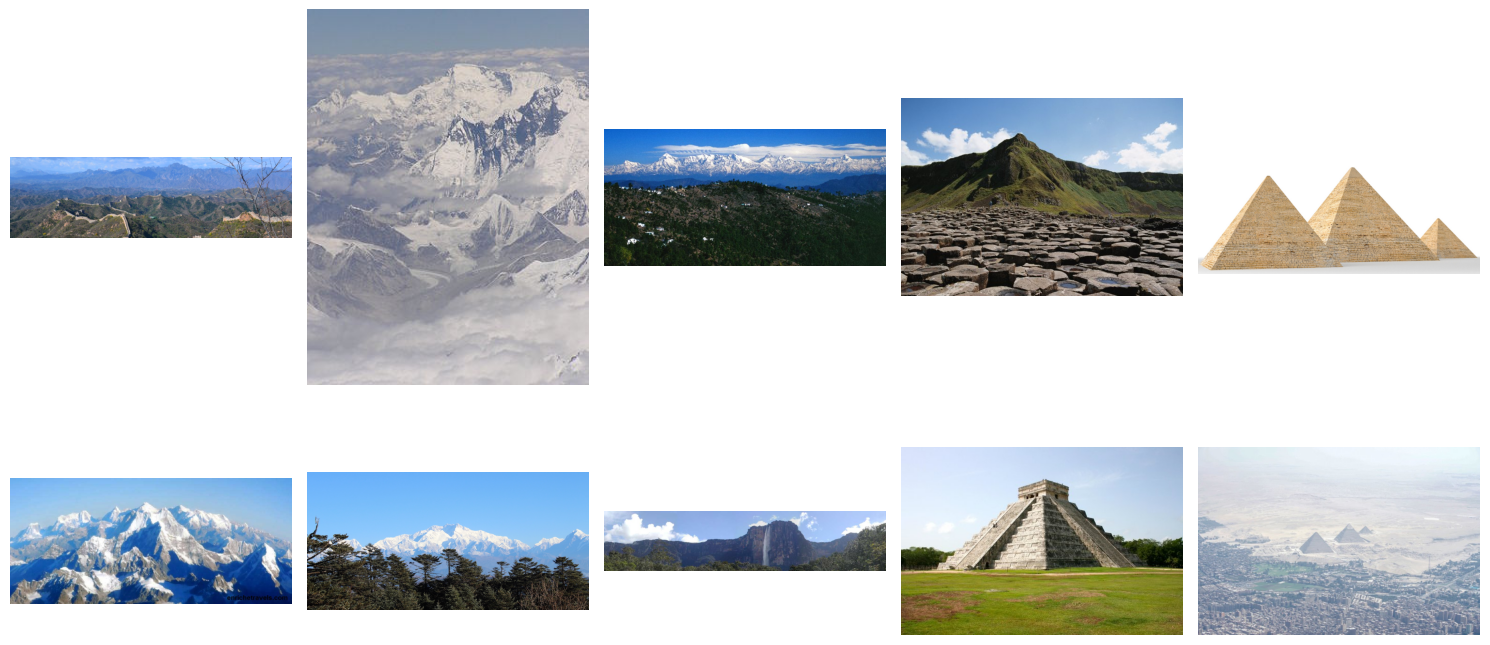

In [37]:
queryImg = "79.jpg"
similar = find_similar_images(queryImg)

# for fname, dist in similar:
#     print(f"{fname}  (distance={dist:.4f})")
similar = find_similar_images(queryImg)

plt.figure(figsize=(15, 8))
plt.subplot(2, 6, 1)
img = mpimg.imread(queryImg)
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(15, 8))
for i, (fname, dist) in enumerate(similar[:10], start=1):
    plt.subplot(2, 5, i)
    similar_image_full_path = os.path.join(pathh, fname)
    img = mpimg.imread(similar_image_full_path)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()